In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from planar_utils import load_planar_dataset, plot_decision_boundary

np.random.seed(1)

X, Y = load_planar_dataset()

print("X shape:", X.shape)
print("Y shape:", Y.shape)

X shape: (2, 400)
Y shape: (1, 400)


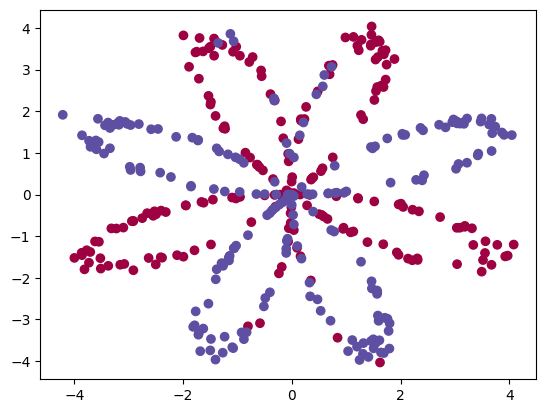

In [ ]:
plt.scatter(X[0, :], X[1, :], c=Y.flatten(), cmap=plt.cm.Spectral)
plt.show()

In [ ]:
def layer_sizes(X, Y):
    n_x = X.shape[0]
    n_h = 4
    n_y = Y.shape[0]
    return n_x, n_h, n_y

n_x, n_h, n_y = layer_sizes(X, Y)
print(n_x, n_h, n_y)

2 4 1


In [ ]:
def initialize_parameters(n_x, n_h, n_y):
    np.random.seed(2)

    W1 = np.random.randn(n_h, n_x) * 0.01
    b1 = np.zeros((n_h, 1))
    W2 = np.random.randn(n_y, n_h) * 0.01
    b2 = np.zeros((n_y, 1))

    parameters = {
        "W1": W1,
        "b1": b1,
        "W2": W2,
        "b2": b2
    }

    return parameters

In [ ]:
def forward_propagation(X, parameters):

    W1 = parameters["W1"]
    b1 = parameters["b1"]
    W2 = parameters["W2"]
    b2 = parameters["b2"]

    Z1 = np.dot(W1, X) + b1
    A1 = np.tanh(Z1)

    Z2 = np.dot(W2, A1) + b2
    A2 = 1 / (1 + np.exp(-Z2))

    cache = {
        "Z1": Z1,
        "A1": A1,
        "Z2": Z2,
        "A2": A2
    }

    return A2, cache

In [ ]:
def compute_cost(A2, Y):

    m = Y.shape[1]

    logprobs = np.multiply(np.log(A2), Y) + np.multiply(np.log(1 - A2), (1 - Y))
    cost = - np.sum(logprobs) / m
    cost = float(np.squeeze(cost))

    return cost

In [ ]:
def backward_propagation(parameters, cache, X, Y):

    m = X.shape[1]

    W2 = parameters["W2"]

    A1 = cache["A1"]
    A2 = cache["A2"]

    dZ2 = A2 - Y
    dW2 = np.dot(dZ2, A1.T) / m
    db2 = np.sum(dZ2, axis=1, keepdims=True) / m

    dZ1 = np.dot(W2.T, dZ2) * (1 - np.power(A1, 2))
    dW1 = np.dot(dZ1, X.T) / m
    db1 = np.sum(dZ1, axis=1, keepdims=True) / m

    grads = {
        "dW1": dW1,
        "db1": db1,
        "dW2": dW2,
        "db2": db2
    }

    return grads

In [ ]:
def update_parameters(parameters, grads, learning_rate=1.2):

    parameters["W1"] -= learning_rate * grads["dW1"]
    parameters["b1"] -= learning_rate * grads["db1"]
    parameters["W2"] -= learning_rate * grads["dW2"]
    parameters["b2"] -= learning_rate * grads["db2"]

    return parameters

In [ ]:
def nn_model(X, Y, n_h, num_iterations=10000, print_cost=False):

    np.random.seed(3)

    n_x = X.shape[0]
    n_y = Y.shape[0]

    parameters = initialize_parameters(n_x, n_h, n_y)

    for i in range(num_iterations):

        A2, cache = forward_propagation(X, parameters)
        cost = compute_cost(A2, Y)
        grads = backward_propagation(parameters, cache, X, Y)
        parameters = update_parameters(parameters, grads)

        if print_cost and i % 1000 == 0:
            print("Cost after iteration %i: %f" % (i, cost))

    return parameters

In [ ]:
def predict(parameters, X):
    A2, _ = forward_propagation(X, parameters)
    predictions = (A2 > 0.5)
    return predictions

In [ ]:
parameters = nn_model(X, Y, n_h=4, num_iterations=10000, print_cost=True)

predictions = predict(parameters, X)

accuracy = float((np.dot(Y, predictions.T) + np.dot(1 - Y, 1 - predictions.T)) / float(Y.size) * 100)

print("Accuracy:", accuracy, "%")

Cost after iteration 0: 0.693048
Cost after iteration 1000: 0.288083
Cost after iteration 2000: 0.254385
Cost after iteration 3000: 0.233864
Cost after iteration 4000: 0.226792
Cost after iteration 5000: 0.222644
Cost after iteration 6000: 0.219731
Cost after iteration 7000: 0.217504
Cost after iteration 8000: 0.219605
Cost after iteration 9000: 0.218598
Accuracy: 90.75 %


/tmp/ipython-input-1149411149.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  accuracy = float((np.dot(Y, predictions.T) + np.dot(1 - Y, 1 - predictions.T)) / float(Y.size) * 100)


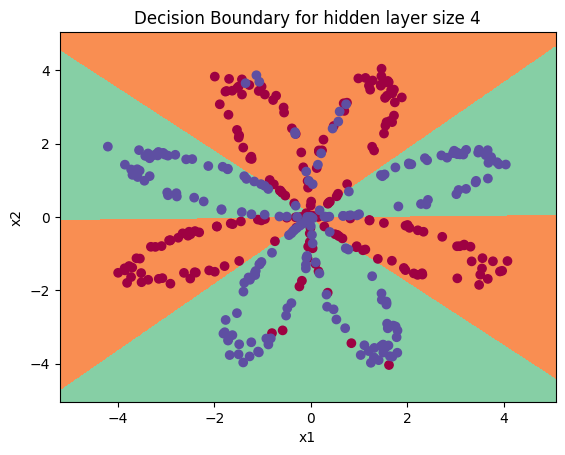

In [ ]:
plot_decision_boundary(lambda x: predict(parameters, x.T), X, Y)
plt.title("Decision Boundary for hidden layer size 4")
plt.show()